# Problem Statement

- FlipItNews is transforming the Indian finance, business, and investment
landscape using AI and ML.
- This case focuses on harnessing natural language processing to categorize
news articles, a critical component for delivering relevant content to users.
- By analyzing its internal database of news articles, FlipItNews aims to
intelligently categorize content into domains like politics, technology, sports,
business, and entertainment.
- The insights from this analysis can significantly improve content discovery and
user engagement, driving financial literacy and investment awareness among
millennials and first-time investors.

# EDA

In [1]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv('flipitnews-data.csv')

In [3]:
df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


## Observations on Data

In [4]:
df.shape

(2225, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


There are no null values 

In [6]:
df.describe()

,Category,Article
count,2225,2225
unique,5,2126
top,Sports,talks aim to avert pension strike talks aimed ...
freq,511,2


There are 5 unique categories and the top category is Sports with 511 articles 

## Univariate Analysis 

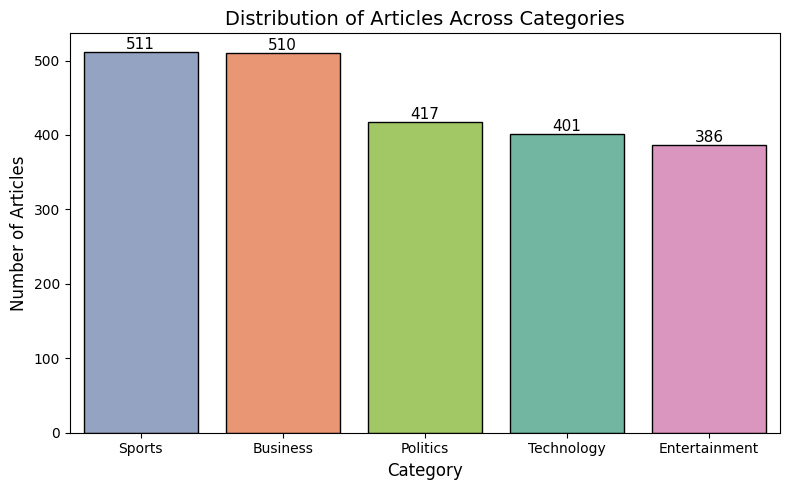

In [9]:
# Count plot - distribution of articles across categories
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Category', hue='Category', legend=False,
                   order=df['Category'].value_counts().index,
                   palette='Set2', edgecolor='black')
plt.title('Distribution of Articles Across Categories', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


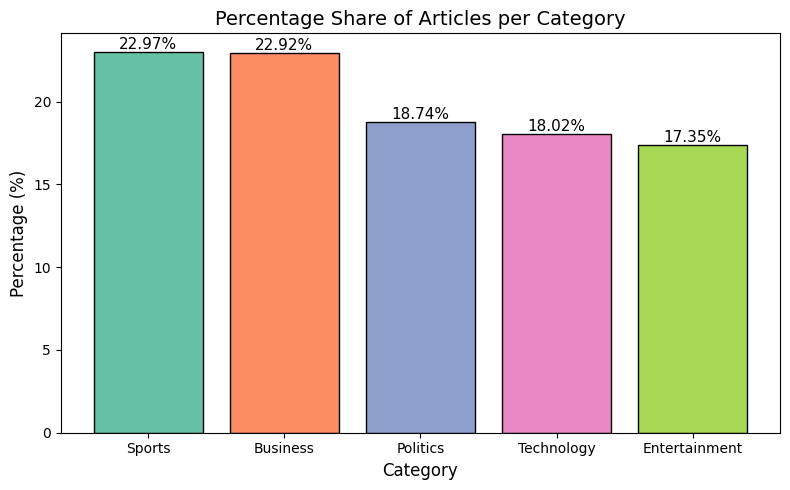

In [10]:
# Bar plot - percentage share of each category
category_counts = df['Category'].value_counts()
category_pct = (category_counts / len(df) * 100).round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_pct.index, category_pct.values,
               color=sns.color_palette('Set2', len(category_pct)), edgecolor='black')
plt.title('Percentage Share of Articles per Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
for bar, val in zip(bars, category_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
             f'{val}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


## Text Data Analysis 


=== Average Word Count per Category ===
Category
Technology       507.4
Politics         461.2
Entertainment    337.7
Sports           336.3
Business         334.2
Name: word_count, dtype: float64


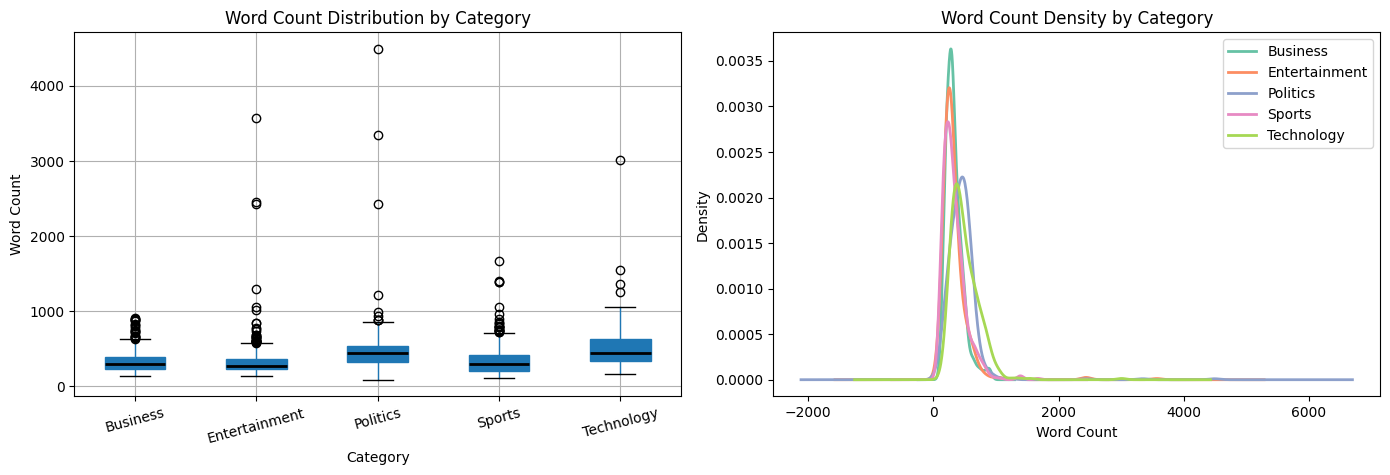

In [7]:

# ── Article Length Analysis ──────────────────────────────────────────────────
df['word_count']  = df['Article'].str.split().str.len()
df['char_count']  = df['Article'].str.len()
df['sent_count']  = df['Article'].str.split(r'[.!?]+').apply(
                        lambda x: len([s for s in x if s.strip()]))


print("\n=== Average Word Count per Category ===")
print(df.groupby('Category')['word_count'].mean().round(1).sort_values(ascending=False))

# Distribution of word counts per category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='word_count', by='Category', ax=axes[0],
           patch_artist=True, medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Word Count Distribution by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Word Count')
plt.sca(axes[0]); plt.xticks(rotation=15)

# KDE / histogram overlay
palette = sns.color_palette('Set2', n_colors=df['Category'].nunique())
for i, (cat, grp) in enumerate(df.groupby('Category')):
    grp['word_count'].plot(kind='kde', ax=axes[1], label=cat, color=palette[i], linewidth=2)
axes[1].set_title('Word Count Density by Category')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()


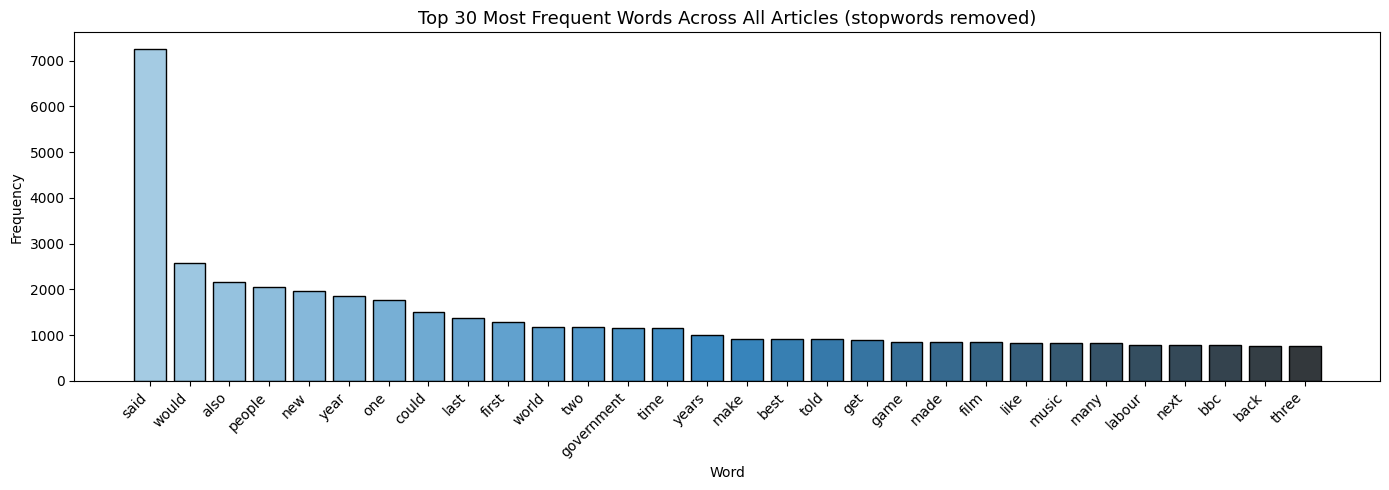


Total unique tokens (after stopword removal): 29,972
Total tokens: 466,902


In [4]:

# ── Top-30 Most Frequent Words (corpus-wide, stopwords removed) ───────────────
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def tokenize(text):
    tokens = re.sub(r'[^a-z\s]', '', str(text).lower()).split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

all_tokens = [tok for article in df['Article'] for tok in tokenize(article)]
top30 = Counter(all_tokens).most_common(30)
words, counts = zip(*top30)

plt.figure(figsize=(14, 5))
bars = plt.bar(words, counts, color=sns.color_palette('Blues_d', 30), edgecolor='black')
plt.title('Top 30 Most Frequent Words Across All Articles (stopwords removed)', fontsize=13)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal unique tokens (after stopword removal): {len(set(all_tokens)):,}")
print(f"Total tokens: {len(all_tokens):,}")


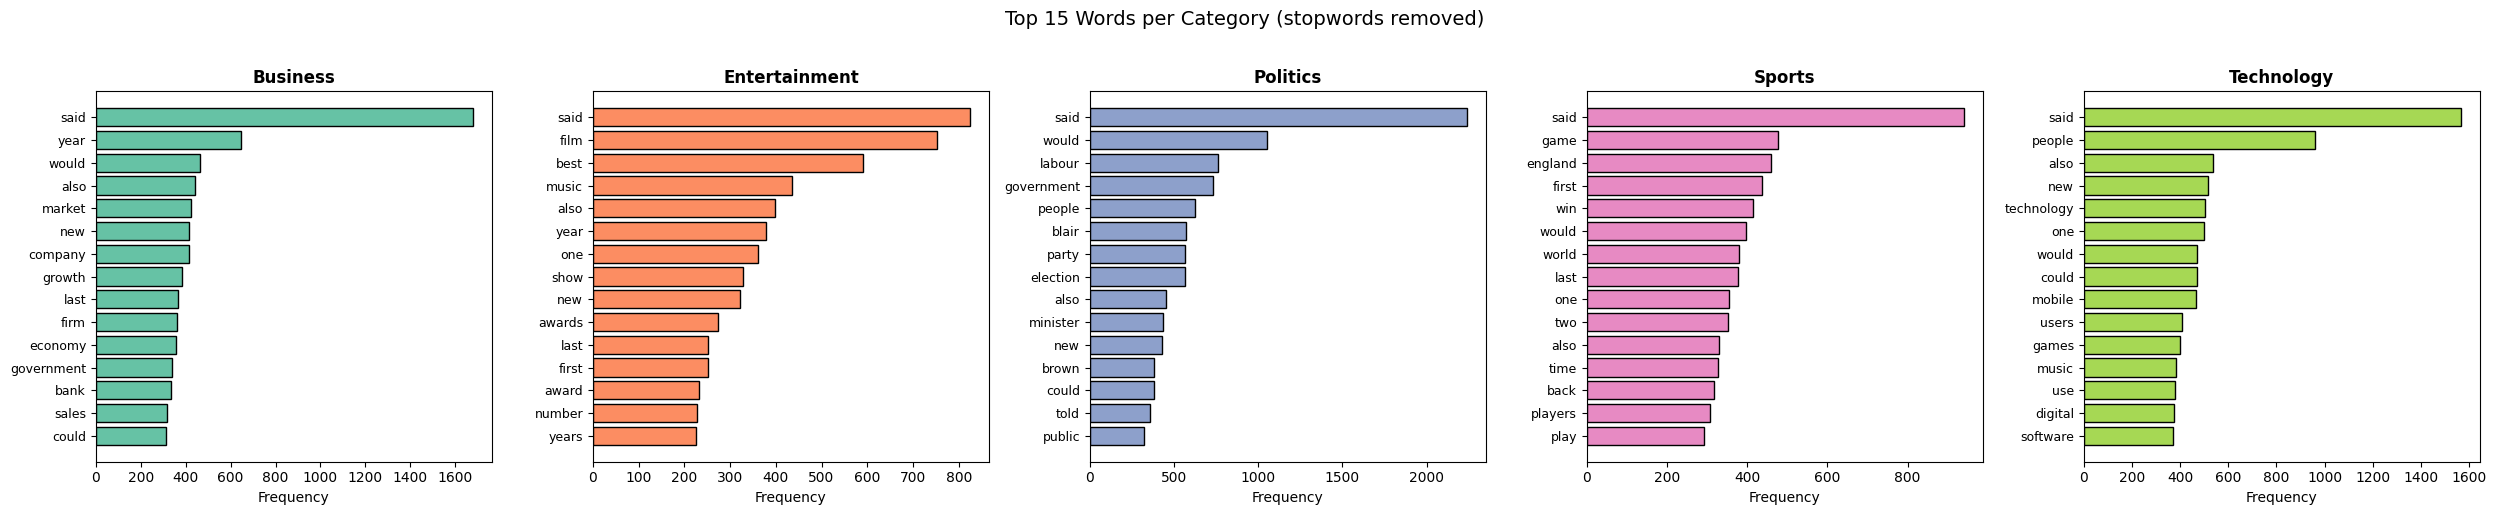

In [5]:

# ── Top-15 Words per Category ─────────────────────────────────────────────────
categories = df['Category'].unique()
n = len(categories)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)

palette = sns.color_palette('Set2', n)

for ax, cat, color in zip(axes, sorted(categories), palette):
    cat_tokens = [tok for article in df[df['Category'] == cat]['Article']
                  for tok in tokenize(article)]
    top15 = Counter(cat_tokens).most_common(15)
    ws, cs = zip(*top15)
    ax.barh(ws[::-1], cs[::-1], color=color, edgecolor='black')
    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 15 Words per Category (stopwords removed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


=== Vocabulary Richness per Category ===
               Total Tokens  Unique Terms  Type-Token Ratio  Avg Unique Tokens/Article
Category                                                                              
Business              94234         11382            0.1208                      134.2
Entertainment         71185         11420            0.1604                      134.1
Politics             101509         11016            0.1085                      169.1
Sports                90138         10432            0.1157                      129.6
Technology           109836         12072            0.1099                      188.2


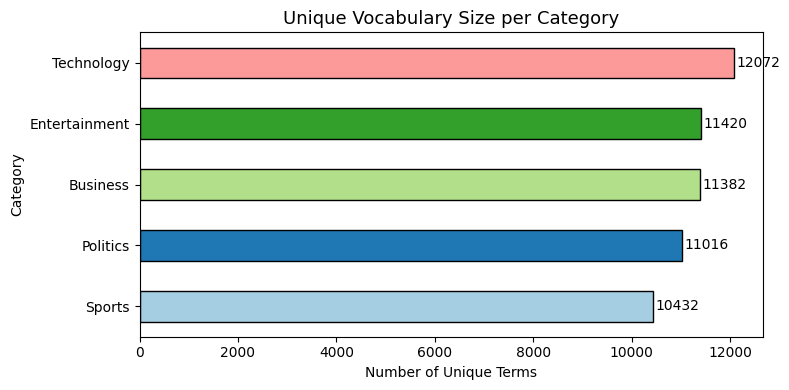

In [6]:

# ── Unique Terms & Vocabulary Richness per Category ───────────────────────────
rows = []
for cat in sorted(df['Category'].unique()):
    cat_tokens = [tok for article in df[df['Category'] == cat]['Article']
                  for tok in tokenize(article)]
    total   = len(cat_tokens)
    unique  = len(set(cat_tokens))
    ttr     = round(unique / total, 4) if total else 0          # Type-Token Ratio
    avg_uq  = round(
        df[df['Category'] == cat]['Article']
          .apply(lambda x: len(set(tokenize(x)))).mean(), 1)    # avg unique tokens/article
    rows.append({'Category': cat, 'Total Tokens': total,
                 'Unique Terms': unique, 'Type-Token Ratio': ttr,
                 'Avg Unique Tokens/Article': avg_uq})

vocab_df = pd.DataFrame(rows).set_index('Category')
print("=== Vocabulary Richness per Category ===")
print(vocab_df.to_string())

# Bar chart – unique terms per category
fig, ax = plt.subplots(figsize=(8, 4))
vocab_df['Unique Terms'].sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('Paired', len(vocab_df)), edgecolor='black')
for i, v in enumerate(vocab_df['Unique Terms'].sort_values()):
    ax.text(v + 50, i, str(v), va='center', fontsize=10)
ax.set_title('Unique Vocabulary Size per Category', fontsize=13)
ax.set_xlabel('Number of Unique Terms')
plt.tight_layout()
plt.show()


## Insights on EDA

### 1. Category Distribution — Thematic Focus
The bar plot reveals that **Sports (22.97%)** and **Business (22.92%)** together account for nearly half the corpus, indicating a strong editorial focus on athletic and financial coverage. **Politics (18.74%)** and **Technology (18.02%)** occupy a mid-range share, while **Entertainment (17.35%)** is the smallest category. Despite having the fewest articles, Technology produces the longest and most vocabulary-rich content (avg. 507 words, 12,072 unique terms), suggesting that tech journalism tends toward in-depth, detailed reporting.

### 2. Article Length & Language Complexity
Article length varies significantly across categories:

| Category | Avg Words | Avg Sentences | Language Complexity |
|---|---|---|---|
| Technology | 507 | ~25 | Highest — long, detailed technical writing |
| Politics | 461 | ~23 | High — analytical, discursive prose |
| Entertainment | 338 | ~17 | Moderate — narrative-driven, shorter features |
| Sports | 336 | ~17 | Moderate — event-driven, formulaic reporting |
| Business | 334 | ~17 | Moderate — concise financial summaries |

The KDE density plots show that **Technology and Politics** have heavier right tails (more long-form articles), while **Sports, Business, and Entertainment** cluster tightly around 200–400 words, reflecting a more standardised article format. The outlier maximum of 4,492 words suggests a small number of investigative or long-read pieces exist in the dataset.

### 3. Predominant Themes per Category (Top-Word Analysis)
The per-category word-frequency bar charts expose clear, non-overlapping thematic clusters — confirming strong separability that should benefit classification models:

- **Business** — *market, company, growth, economy, shares, profit* → financial performance and corporate activity  
- **Entertainment** — *film, music, award, star, album, show* → celebrity culture and media production  
- **Politics** — *labour, government, blair, election, party, minister* → UK-centric political events (2001–2005 Parliament period)  
- **Sports** — *game, england, win, cup, match, team, players* → match results and tournament coverage  
- **Technology** — *technology, mobile, users, software, broadband, digital* → consumer tech adoption and digital infrastructure  

The corpus-wide top words (`said`, `would`, `also`, `year`) are journalistic filler terms that survive stopword removal. A second-pass custom stoplist removing these domain-neutral words would further sharpen category signals during modelling.

### 4. Vocabulary Richness & Language Diversity
The vocabulary analysis (Type-Token Ratio and unique term counts) reveals distinct writing styles across categories:

- **Entertainment (TTR = 0.160)** shows the highest lexical diversity per token — entertainment writers employ a wider range of expressive vocabulary within a shorter article format.  
- **Politics (TTR = 0.109)** and **Technology (TTR = 0.110)** score lower despite large raw vocabularies, because their high article counts and long texts repeat domain-specific terms frequently (e.g., *government*, *technology*, *users*).  
- **Sports (TTR = 0.116, 10,432 unique terms)** has the smallest vocabulary and is the most formulaic — match reporting reuses a narrow set of action words and proper nouns.  
- **Technology** leads in absolute vocabulary size (12,072 unique terms) and average unique tokens per article (188), reflecting the breadth of sub-topics (mobile, broadband, software, digital) covered under one category label.  

**Overall takeaway:** The dataset is well-suited for NLP classification. The clear thematic separation visible in word distributions, combined with consistent article lengths within categories, suggests that both Bag-of-Words and TF-IDF vectorisers should capture strong discriminating features for models like Naive Bayes, Random Forest, and KNN.